In [1]:
import pandas as pd
print("Đã import thành công pandas!")


Đã import thành công pandas!


In [2]:
df4 = pd.read_csv('BT4.313092302_satisfaction_level.csv')

print("=== 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ===")
display(df4.head())

print("\n=== THÔNG TIN BỘ DỮ LIỆU ===")
df4.info()

=== 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ===


,Repair_Time,Waiting_Time,Satisfaction_Level
0,2.5,1.0,4
1,3.0,1.2,3
2,4.2,1.5,2
3,2.8,0.8,4
4,5.0,2.0,2



=== THÔNG TIN BỘ DỮ LIỆU ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Repair_Time         60 non-null     float64
 1   Waiting_Time        60 non-null     float64
 2   Satisfaction_Level  60 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 1.5 KB


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Đã import numpy, LinearRegression, matplotlib và mplot3d!")

Đã import numpy, LinearRegression, matplotlib và mplot3d!


In [4]:
X4 = df4[['Repair_Time', 'Waiting_Time']]
y4 = df4['Satisfaction_Level']

model4 = LinearRegression()
model4.fit(X4, y4)

print("Đã huấn luyện xong mô hình hồi quy tuyến tính đa biến!")

Đã huấn luyện xong mô hình hồi quy tuyến tính đa biến!


In [5]:
y_pred4 = model4.predict(X4)

df_compare4 = pd.DataFrame({
    'Repair_Time': df4['Repair_Time'],
    'Waiting_Time': df4['Waiting_Time'],
    'Actual (Thực tế)': y4,
    'Predicted (Dự đoán)': np.round(y_pred4, 2),
    'Sai số (Residual)': np.round(y4 - y_pred4, 2)
})

display(df_compare4.head())


,Repair_Time,Waiting_Time,Actual (Thực tế),Predicted (Dự đoán),Sai số (Residual)
0,2.5,1.0,4,4.28,-0.28
1,3.0,1.2,3,3.72,-0.72
2,4.2,1.5,2,2.45,-0.45
3,2.8,0.8,4,4.10,-0.10
4,5.0,2.0,2,1.47,0.53


In [6]:
intercept4 = model4.intercept_
coef_repair = model4.coef_[0]
coef_waiting = model4.coef_[1]

print("=== CÁC HỆ SỐ CỦA MÔ HÌNH HỒI QUY ĐA BIẾN ===")
print(f"Hệ số chặn (Intercept / w0)     : {intercept4:.4f}")
print(f"Hệ số của Repair_Time (Slope w1): {coef_repair:.4f}")
print(f"Hệ số của Waiting_Time (Slope w2): {coef_waiting:.4f}")

print("\n=== KẾT LUẬN HÀM MÔ HÌNH HỒI QUY ===")
print(f"Satisfaction_Level = {intercept4:.4f} + ({coef_repair:.4f}) * Repair_Time + ({coef_waiting:.4f}) * Waiting_Time")

=== CÁC HỆ SỐ CỦA MÔ HÌNH HỒI QUY ĐA BIẾN ===
Hệ số chặn (Intercept / w0)     : 7.0957
Hệ số của Repair_Time (Slope w1): -0.9337
Hệ số của Waiting_Time (Slope w2): -0.4802

=== KẾT LUẬN HÀM MÔ HÌNH HỒI QUY ===
Satisfaction_Level = 7.0957 + (-0.9337) * Repair_Time + (-0.4802) * Waiting_Time


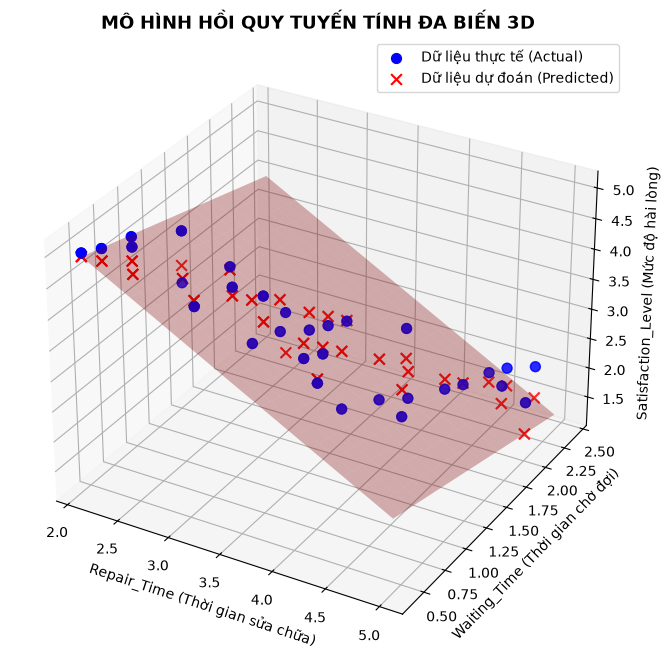

In [7]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df4['Repair_Time'], df4['Waiting_Time'], y4, 
           color='blue', s=50, label='Dữ liệu thực tế (Actual)')

ax.scatter(df4['Repair_Time'], df4['Waiting_Time'], y_pred4, 
           color='red', marker='x', s=60, label='Dữ liệu dự đoán (Predicted)')

repair_range = np.linspace(df4['Repair_Time'].min(), df4['Repair_Time'].max(), 20)
waiting_range = np.linspace(df4['Waiting_Time'].min(), df4['Waiting_Time'].max(), 20)
repair_grid, waiting_grid = np.meshgrid(repair_range, waiting_range)
satisfaction_plane = intercept4 + coef_repair * repair_grid + coef_waiting * waiting_grid

ax.plot_surface(repair_grid, waiting_grid, satisfaction_plane, 
                color='red', alpha=0.3, edgecolor='none')

ax.set_title('MÔ HÌNH HỒI QUY TUYẾN TÍNH ĐA BIẾN 3D', fontsize=13, fontweight='bold')
ax.set_xlabel('Repair_Time (Thời gian sửa chữa)', fontsize=10)
ax.set_ylabel('Waiting_Time (Thời gian chờ đợi)', fontsize=10)
ax.set_zlabel('Satisfaction_Level (Mức độ hài lòng)', fontsize=10)
ax.legend(loc='upper right')
plt.show()


In [8]:
mse4 = mean_squared_error(y4, y_pred4)
rmse4 = np.sqrt(mse4)
r2_4 = r2_score(y4, y_pred4)

print("=== CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH ===")
print(f"1. Mean Squared Error (MSE)      : {mse4:.4f}")
print(f"2. Root Mean Squared Error (RMSE): {rmse4:.4f}")
print(f"3. R-squared (R2 Score)           : {r2_4:.4f} ({r2_4 * 100:.2f}%)")

print("\n=== NHẬN XÉT ===")
print(f"• R-squared đạt {r2_4:.4f} ({r2_4 * 100:.2f}%): Mô hình giải thích tốt 85.07% sự biến thiên của mức độ hài lòng.")
print(f"• Sai số RMSE là {rmse4:.4f}: Sai lệch dự đoán trung bình thấp.")
print("=> Cả thời gian sửa chữa và thời gian chờ đợi đều tỉ lệ nghịch với mức độ hài lòng của khách hàng.")

=== CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH ===
1. Mean Squared Error (MSE)      : 0.1765
2. Root Mean Squared Error (RMSE): 0.4202
3. R-squared (R2 Score)           : 0.8507 (85.07%)

=== NHẬN XÉT ===
• R-squared đạt 0.8507 (85.07%): Mô hình giải thích tốt 85.07% sự biến thiên của mức độ hài lòng.
• Sai số RMSE là 0.4202: Sai lệch dự đoán trung bình thấp.
=> Cả thời gian sửa chữa và thời gian chờ đợi đều tỉ lệ nghịch với mức độ hài lòng của khách hàng.
